In [1]:
#Instalação de Pacotes, inclusive para imprimir gráficos
#Execute esta célula antes dos demais exemplos. A instalação precisa ser refeita sempre que uma nova sessão do. Google Colab for iniciada.

!pip install -q qiskit qiskit-aer pylatexenc matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.4 MB/s eta 0:00:00


In [ ]:
#LAB1: VERIFICANDO A VERSÃO DOO QSKIT

# [MÓDULO / IMPORTAÇÃO]
# Importa o módulo `sys`, pertencente à biblioteca padrão do Python.
# Neste código, ele será utilizado para consultar a versão do ambiente Python.
# Ainda não há aqui qualquer operação de computação quântica.
import sys


# [PACOTE / IMPORTAÇÃO]
# Importa o pacote `qiskit`.
# O Qiskit fornece as ferramentas que serão utilizadas posteriormente
# para representar circuitos, qubits, portas, medições e formas de execução.
# Nesta linha, porém, estamos apenas carregando o pacote.
import qiskit


# [FUNÇÃO + ATRIBUTO]
# `print()` é uma função nativa (built-in) do Python.
# "Python:" é uma string passada como primeiro argumento.
# `sys.version` é o atributo `version` do módulo `sys`.
# Esse atributo contém informações sobre a versão do Python em execução.
#
# Finalidade: documentar o ambiente no qual o código foi executado.
print("Python:", sys.version)


# [FUNÇÃO + ATRIBUTO]
# `print()` é novamente uma função nativa do Python.
# `qiskit.__version__` é um atributo do pacote `qiskit`.
# Ele fornece a versão instalada do Qiskit.
#
# Finalidade: registrar a versão do Qiskit utilizada no experimento,
# informação importante para reprodução e compatibilidade do código.
print("Qiskit:", qiskit.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Qiskit: 2.5.2


In [ ]:
#LAB2: CRIANDO CIRCUITO, APLICANDO UMA PORTA E VISUALIZANDO O CIRCUITO

# [CLASSE / IMPORTAÇÃO]
# Importa a classe `QuantumCircuit` do pacote `qiskit`.
#
# `QuantumCircuit` é a classe utilizada pelo Qiskit para construir
# e representar circuitos quânticos.
from qiskit import QuantumCircuit


# [OBJETO / INSTANCIAÇÃO DE CLASSE]
# `QuantumCircuit(1)` instancia a classe QuantumCircuit.
# O argumento `1` determina que o circuito terá um registrador
# quântico contendo um único qubit.
#
# A variável `circuito` passa a referenciar esse objeto.
#
# [COMPUTAÇÃO QUÂNTICA]
# Por padrão, o qubit é inicializado no estado |0>.
circuito = QuantumCircuit(1)


# [MÉTODO]
# Chama o método `h()` do objeto `circuito`.
# O argumento `0` indica que a operação será aplicada ao qubit
# de índice 0, isto é, q_0.
#
# [COMPUTAÇÃO QUÂNTICA]
# Adiciona ao circuito uma porta Hadamard (H).
#
# Como o qubit estava inicialmente em |0>, temos:
#
#             |0> + |1>
# H|0> = -------------------
#                sqrt(2)
#
# O qubit passa para o estado |+>, uma superposição dos estados
# da base computacional |0> e |1>.
circuito.h(0)


# [MÉTODO]
# Chama o método `measure_all()` do objeto `circuito`.
#
# O método acrescenta operações de medição para todos os qubits
# do circuito e cria os bits clássicos necessários para armazenar
# os resultados.
#
# [COMPUTAÇÃO QUÂNTICA]
# A medição será realizada na base computacional {|0>, |1>}.
#
# Para o estado |+>, as probabilidades teóricas são:
#
# P(0) = 1/2
# P(1) = 1/2
#
# Portanto, em muitas execuções, esperamos aproximadamente
# 50% de resultados 0 e 50% de resultados 1.
circuito.measure_all()


# [FUNÇÃO]
# `print()` é uma função nativa do Python.
# O objeto `circuito` é passado como argumento.
#
# Como QuantumCircuit possui uma representação textual,
# o Python/Qiskit produz no terminal uma representação
# do circuito construído.
#
# Esta linha NÃO executa o circuito quântico.
# Ela apenas exibe sua estrutura.
print(circuito)

        ┌───┐ ░ ┌─┐
     q: ┤ H ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0 


{'0': 529, '1': 495}
        ┌───┐ ░ ┌─┐
     q: ┤ H ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0 


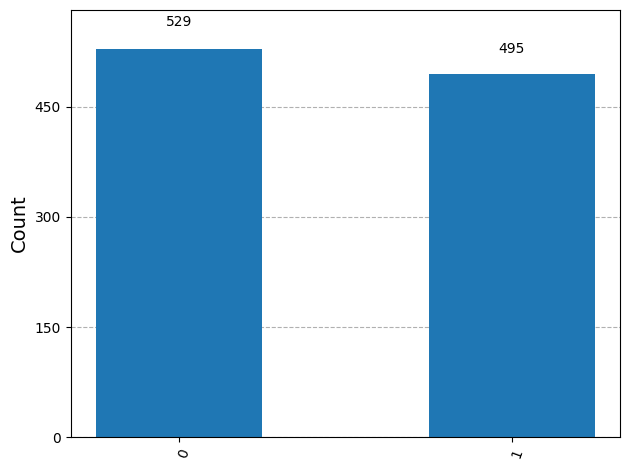

In [ ]:
#LAB3: CRIANDO CIRCUITO, APLICANDO UMA PORTA, FAZENDO A MEDIÇÃO E VERIFICANDO A MEDIÇÃO

# [CLASSE / IMPORTAÇÃO]
# Importa a classe `QuantumCircuit` do pacote `qiskit`.
#
# QuantumCircuit é a classe utilizada para criar e representar
# circuitos quânticos no Qiskit.
from qiskit import QuantumCircuit


# [CLASSE / IMPORTAÇÃO]
# Importa a classe `StatevectorSampler` de `qiskit.primitives`.
#
# O StatevectorSampler permite obter amostras de resultados
# de medição utilizando uma simulação ideal baseada
# na representação por vetor de estado.
from qiskit.primitives import StatevectorSampler


# [FUNÇÃO / IMPORTAÇÃO]
# Importa a função `plot_histogram` do módulo
# `qiskit.visualization`.
#
# Diferentemente de QuantumCircuit e StatevectorSampler,
# `plot_histogram` não é uma classe: é uma FUNÇÃO.
#
# Ela será utilizada posteriormente para transformar
# as contagens obtidas em uma representação gráfica.
from qiskit.visualization import plot_histogram


# [OBJETO / INSTANCIAÇÃO]
# `QuantumCircuit(1)` instancia a classe QuantumCircuit.
#
# O argumento `1` determina a criação de um circuito
# contendo um único qubit.
#
# A variável `circuito` referencia o objeto criado.
#
# [COMPUTAÇÃO QUÂNTICA]
# O qubit é inicialmente preparado no estado |0>.
circuito = QuantumCircuit(1)


# [MÉTODO]
# Chama o método `h()` do objeto `circuito`.
#
# O argumento `0` indica que a operação deve atuar
# sobre o qubit de índice 0 (q_0).
#
# [COMPUTAÇÃO QUÂNTICA]
# Acrescenta uma porta Hadamard H ao circuito.
#
# Para o estado inicial |0>:
#
#                  |0> + |1>
# H|0> = |+> = ----------------
#                    sqrt(2)
#
# Portanto, produzimos uma superposição.
circuito.h(0)


# [MÉTODO]
# Chama o método `measure_all()` do objeto `circuito`.
#
# O método acrescenta operações de medição para todos
# os qubits e os bits clássicos necessários para
# armazenar os resultados.
#
# [COMPUTAÇÃO QUÂNTICA]
# O estado |+> será medido na base computacional.
#
# P(0) = 1/2
# P(1) = 1/2
circuito.measure_all()


# [OBJETO / INSTANCIAÇÃO]
# `StatevectorSampler()` instancia a classe StatevectorSampler.
#
# A variável `sampler` referencia o objeto criado.
#
# Esse objeto será utilizado para realizar a amostragem
# dos resultados de medição.
sampler = StatevectorSampler()


# [MÉTODOS + ARGUMENTOS]
# `sampler.run()` chama o método `run()` do objeto sampler.
#
# `[circuito]` é uma lista contendo o circuito submetido.
#
# `shots=1024` é um argumento nomeado que solicita
# 1024 amostras de medição.
#
# `.result()` obtém o resultado da execução.
#
# O resultado é armazenado na variável `resultado`.
resultado = sampler.run([circuito], shots=1024).result()


# [INDEXAÇÃO + ATRIBUTOS + MÉTODO]
# `resultado[0]` seleciona o resultado referente ao
# primeiro circuito submetido.
#
# `.data` acessa os dados desse resultado.
#
# `.meas` acessa os dados correspondentes à medição.
#
# `.get_counts()` chama o método que agrega os resultados
# e devolve suas respectivas contagens.
#
# O resultado é armazenado na variável `contagens`.
contagens = resultado[0].data.meas.get_counts()


# [FUNÇÃO]
# `print()` é uma função nativa do Python.
#
# A variável `contagens` é passada como argumento.
#
# Uma saída possível seria:
#
# {'0': 507, '1': 517}
#
# Os valores específicos podem variar entre execuções.
print(contagens)


# [FUNÇÃO + OBJETO]
# `print()` recebe agora o objeto `circuito`.
#
# O Qiskit fornece uma representação textual desse objeto,
# permitindo visualizar a sequência de operações do circuito.
#
# IMPORTANTE:
# esta linha NÃO executa novamente o circuito.
# Apenas exibe sua representação textual.
print(circuito)


# [FUNÇÃO DE VISUALIZAÇÃO]
# Chama a função `plot_histogram()`, importada de
# `qiskit.visualization`.
#
# `contagens` é fornecida como argumento.
#
# A função transforma as contagens dos resultados de medição
# em uma representação gráfica.
#
# IMPORTANTE:
# plot_histogram() NÃO realiza uma operação quântica,
# NÃO mede o qubit e NÃO executa o circuito.
# Ela apenas visualiza dados clássicos já obtidos.
plot_histogram(contagens)


{'1': 1024}
        ┌───┐ ░ ┌─┐
     q: ┤ X ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0 


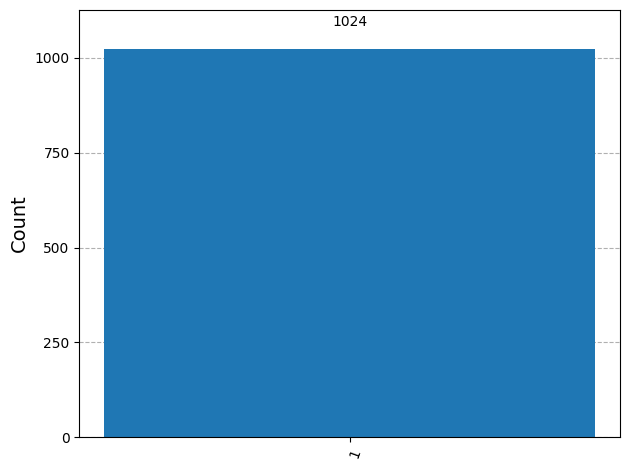

In [ ]:
#LAB3-B: CONTINUAÇÃO DO ANTERIOR,MAS COM UMA PORTA DIFERENTE

# [CLASSE / IMPORTAÇÃO]
# Importa a classe `QuantumCircuit` do pacote `qiskit`.
#
# QuantumCircuit é a classe utilizada para criar e representar
# circuitos quânticos no Qiskit.
from qiskit import QuantumCircuit


# [CLASSE / IMPORTAÇÃO]
# Importa a classe `StatevectorSampler` do módulo
# `qiskit.primitives`.
#
# Ela será utilizada para realizar uma amostragem ideal
# dos resultados de medição do circuito.
from qiskit.primitives import StatevectorSampler


# [FUNÇÃO / IMPORTAÇÃO]
# Importa a função `plot_histogram` do módulo
# `qiskit.visualization`.
#
# Essa função será utilizada posteriormente para representar
# graficamente as contagens obtidas.
from qiskit.visualization import plot_histogram


# [OBJETO / INSTANCIAÇÃO]
# `QuantumCircuit(1)` instancia a classe QuantumCircuit.
#
# O argumento `1` determina que o circuito possui um único qubit.
#
# A variável `circuito` referencia o objeto criado.
#
# [COMPUTAÇÃO QUÂNTICA]
# Por padrão, esse qubit começa no estado |0>.
circuito = QuantumCircuit(1)


# [MÉTODO]
# Chama o método `x()` do objeto `circuito`.
#
# O argumento `0` indica que a operação será aplicada
# ao qubit de índice 0, isto é, q_0.
#
# [COMPUTAÇÃO QUÂNTICA]
# Acrescenta ao circuito a porta Pauli-X.
#
# Para o estado inicial |0>:
#
# X|0> = |1>
#
# Portanto, a porta X inverte o estado da base computacional:
#
# |0> ---> |1>
# |1> ---> |0>
circuito.x(0)


# [MÉTODO]
# Chama o método `measure_all()` do objeto `circuito`.
#
# O método acrescenta a medição de todos os qubits
# e os bits clássicos necessários para armazenar os resultados.
#
# [COMPUTAÇÃO QUÂNTICA]
# Como o estado imediatamente antes da medição é |1>,
# uma medição na base computacional produz:
#
# P(0) = 0
# P(1) = 1
circuito.measure_all()


# [OBJETO / INSTANCIAÇÃO]
# `StatevectorSampler()` instancia a classe StatevectorSampler.
#
# A variável `sampler` referencia esse objeto.
#
# Ele será utilizado para realizar a amostragem ideal
# dos resultados de medição.
sampler = StatevectorSampler()


# [MÉTODO + ARGUMENTOS]
# `sampler.run()` chama o método `run()` do objeto sampler.
#
# `[circuito]` é uma lista contendo o circuito submetido.
#
# `shots=1024` é um argumento nomeado que determina
# a realização de 1024 amostras.
#
# `.result()` obtém o resultado produzido pela execução.
#
# O resultado é armazenado na variável `resultado`.
resultado = sampler.run([circuito], shots=1024).result()


# [INDEXAÇÃO + ATRIBUTOS + MÉTODO]
# `resultado[0]` seleciona o resultado correspondente
# ao primeiro circuito submetido.
#
# `.data` acessa os dados desse resultado.
#
# `.meas` acessa os dados associados à medição.
#
# `.get_counts()` é o método que recupera as contagens
# dos resultados observados.
#
# O resultado é armazenado na variável `contagens`.
contagens = resultado[0].data.meas.get_counts()


# [FUNÇÃO]
# `print()` é uma função nativa do Python.
#
# Exibe as contagens obtidas.
#
# Como estamos utilizando uma simulação ideal e o estado
# medido é |1>, esperamos:
#
# {'1': 1024}
print(contagens)


# [FUNÇÃO + OBJETO]
# `print()` recebe o objeto `circuito` como argumento.
#
# O Qiskit produz uma representação textual do circuito.
#
# Esta operação NÃO executa o circuito.
# Apenas mostra sua estrutura.
print(circuito)


# [FUNÇÃO DE VISUALIZAÇÃO]
# Chama a função `plot_histogram()`.
#
# A variável `contagens` é fornecida como argumento.
#
# A função representa graficamente as frequências
# dos resultados já obtidos.
#
# Ela NÃO executa o circuito e NÃO realiza uma medição.
# Apenas visualiza dados clássicos.
plot_histogram(contagens)


{'1': 1024}
        ┌───┐ ░ ┌─┐
     q: ┤ X ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0 


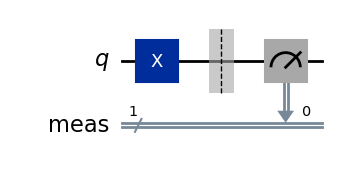

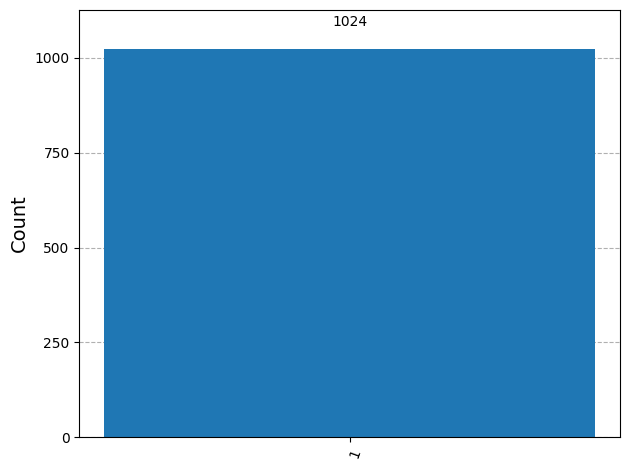

In [ ]:
#LAB3C: CONTINUAÇÃO DO ANTERIOR, MAS COM UMA VISUALIZAÇÃO MELHOR DO CIRCUITO

# [CLASSE / IMPORTAÇÃO]
# Importa a classe `QuantumCircuit` do pacote `qiskit`.
#
# QuantumCircuit é a classe utilizada para criar e representar
# circuitos quânticos.
from qiskit import QuantumCircuit


# [CLASSE / IMPORTAÇÃO]
# Importa a classe `StatevectorSampler` do módulo
# `qiskit.primitives`.
#
# O StatevectorSampler será utilizado para realizar
# uma amostragem ideal dos resultados de medição.
from qiskit.primitives import StatevectorSampler


# [FUNÇÃO / IMPORTAÇÃO]
# Importa a função `plot_histogram` do módulo
# `qiskit.visualization`.
#
# Essa função será utilizada para representar graficamente
# as contagens obtidas após a execução.
from qiskit.visualization import plot_histogram


# [FUNÇÃO / IMPORTAÇÃO]
# Importa a função `display` do módulo `IPython.display`.
#
# IMPORTANTE:
# `display` não pertence ao Qiskit.
# É uma função fornecida pelo ambiente IPython/Jupyter
# para exibir objetos de maneira apropriada no notebook.
from IPython.display import display


# [OBJETO / INSTANCIAÇÃO]
# `QuantumCircuit(1)` instancia a classe QuantumCircuit.
#
# O argumento `1` determina que o circuito possui um qubit.
#
# A variável `circuito` referencia o objeto criado.
#
# [COMPUTAÇÃO QUÂNTICA]
# O qubit é inicializado, por padrão, no estado |0>.
circuito = QuantumCircuit(1)


# [MÉTODO]
# Chama o método `x()` do objeto `circuito`.
#
# O argumento `0` identifica o qubit q_0.
#
# [COMPUTAÇÃO QUÂNTICA]
# Acrescenta uma porta Pauli-X ao circuito:
#
# X|0> = |1>
#
# Portanto, o estado do qubit passa de |0> para |1>.
circuito.x(0)


# [MÉTODO]
# Chama o método `measure_all()` do objeto `circuito`.
#
# Acrescenta a medição do qubit e o bit clássico
# necessário para armazenar o resultado.
#
# [COMPUTAÇÃO QUÂNTICA]
# Como o estado antes da medição é |1>:
#
# P(0) = 0
# P(1) = 1
circuito.measure_all()


# [OBJETO / INSTANCIAÇÃO]
# `StatevectorSampler()` instancia a classe StatevectorSampler.
#
# A variável `sampler` referencia esse objeto.
sampler = StatevectorSampler()


# [MÉTODOS + ARGUMENTOS]
# `run()` é um método do objeto `sampler`.
#
# `[circuito]` é uma lista contendo o circuito submetido.
#
# `shots=1024` é um argumento nomeado que solicita
# 1024 amostras de medição.
#
# `.result()` recupera o resultado da execução.
#
# O resultado é armazenado na variável `resultado`.
resultado = sampler.run([circuito], shots=1024).result()


# [INDEXAÇÃO + ATRIBUTOS + MÉTODO]
# `resultado[0]` seleciona o primeiro resultado.
#
# `.data` acessa seus dados.
#
# `.meas` acessa os dados associados à medição.
#
# `.get_counts()` recupera as contagens dos resultados.
#
# O resultado é armazenado na variável `contagens`.
contagens = resultado[0].data.meas.get_counts()


# [FUNÇÃO]
# `print()` é uma função nativa do Python.
#
# Exibe as contagens.
#
# Para esta simulação ideal, esperamos:
#
# {'1': 1024}
print(contagens)


# [FUNÇÃO + OBJETO]
# `print()` recebe o objeto `circuito`.
#
# O Qiskit fornece uma representação textual do circuito.
#
# Essa linha NÃO executa o circuito.
print(circuito)


# [FUNÇÃO + MÉTODO + ARGUMENTO NOMEADO]
# `circuito.draw()` chama o método `draw()` do objeto circuito.
#
# `output="mpl"` é um argumento nomeado.
#
# "mpl" solicita ao Qiskit uma representação gráfica
# utilizando o backend de desenho baseado em Matplotlib.
#
# O objeto gráfico retornado por `draw()` é passado como
# argumento para a função `display()`, que o exibe no notebook.
#
# IMPORTANTE:
# esta linha NÃO executa o circuito.
# Ela apenas produz e exibe sua representação gráfica.
display(circuito.draw(output="mpl"))


# [FUNÇÃO DE VISUALIZAÇÃO]
# `plot_histogram()` é uma função do módulo
# `qiskit.visualization`.
#
# Recebe `contagens` como argumento e produz
# uma representação gráfica das frequências observadas.
#
# Também não executa qualquer operação quântica:
# trabalha com dados clássicos já obtidos.
plot_histogram(contagens)

{'1': 1024}
        ┌───┐┌───┐┌───┐ ░ ┌─┐
     q: ┤ H ├┤ Z ├┤ H ├─░─┤M├
        └───┘└───┘└───┘ ░ └╥┘
meas: 1/═══════════════════╩═
                           0 


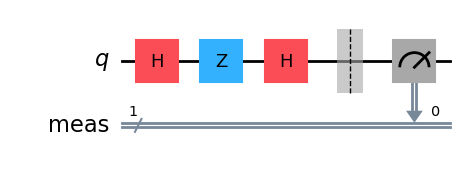

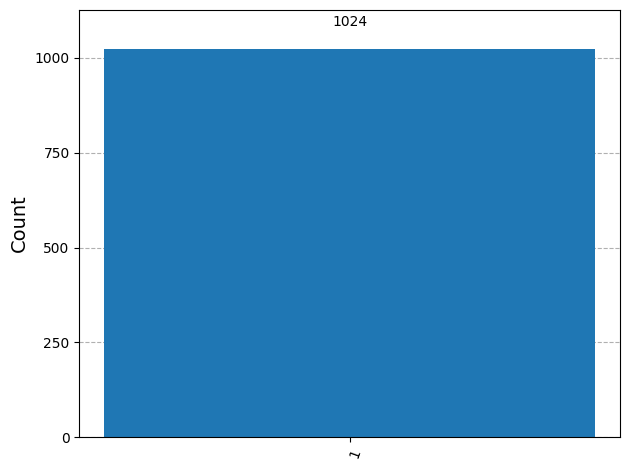

In [ ]:
#LAB3D: CONTINUAÇÃO DO ANTERIOR, MAS COM MAIS DE UMA PORTA APLICADA EM SÉRIE

# [CLASSE / IMPORTAÇÃO]
# Importa a classe `QuantumCircuit` do pacote `qiskit`.
#
# QuantumCircuit é utilizada para criar e representar
# circuitos quânticos.
from qiskit import QuantumCircuit


# [CLASSE / IMPORTAÇÃO]
# Importa a classe `StatevectorSampler` do módulo
# `qiskit.primitives`.
#
# O StatevectorSampler será utilizado para produzir
# amostras dos resultados de medição em uma simulação ideal.
from qiskit.primitives import StatevectorSampler


# [FUNÇÃO / IMPORTAÇÃO]
# Importa a função `plot_histogram` do módulo
# `qiskit.visualization`.
#
# Essa função será utilizada para representar graficamente
# as contagens obtidas.
from qiskit.visualization import plot_histogram


# [FUNÇÃO / IMPORTAÇÃO]
# Importa a função `display` do módulo `IPython.display`.
#
# Essa função pertence ao ambiente IPython/Jupyter,
# e não ao Qiskit.
#
# Será utilizada para exibir graficamente o circuito.
from IPython.display import display


# [OBJETO / INSTANCIAÇÃO]
# `QuantumCircuit(1)` instancia a classe QuantumCircuit
# com um único qubit.
#
# A variável `circuito` referencia o objeto criado.
#
# [COMPUTAÇÃO QUÂNTICA]
# Por padrão, o qubit começa no estado |0>.
circuito = QuantumCircuit(1)


# [MÉTODO]
# Chama o método `h()` do objeto `circuito`.
#
# O argumento `0` indica que a porta Hadamard será
# aplicada ao qubit q_0.
#
# [COMPUTAÇÃO QUÂNTICA]
# A primeira Hadamard transforma:
#
#                 |0> + |1>
# |0> ---> |+> = -----------
#                   sqrt(2)
#
# Portanto, produzimos uma superposição.
circuito.h(0)


# [MÉTODO]
# Chama o método `z()` do objeto `circuito`.
#
# O argumento `0` indica novamente o qubit q_0.
#
# [COMPUTAÇÃO QUÂNTICA]
# Acrescenta uma porta Pauli-Z ao circuito.
#
# A porta Z mantém |0> e altera o sinal de |1>:
#
# Z|0> = |0>
# Z|1> = -|1>
#
# Portanto:
#
#       |0> + |1>                 |0> - |1>
# Z ----------------  =  ----------------
#         sqrt(2)                    sqrt(2)
#
# Isto é:
#
# Z|+> = |->
#
# A porta Z introduz aqui uma diferença de fase relativa.
circuito.z(0)


# [MÉTODO]
# Chama novamente o método `h()` sobre o qubit q_0.
#
# [COMPUTAÇÃO QUÂNTICA]
# A segunda Hadamard transforma o estado |-> em |1>:
#
# H|-> = |1>
#
# Essa etapa é especialmente importante:
# a diferença de fase introduzida por Z passa a produzir
# uma diferença observável na base computacional.
circuito.h(0)


# [MÉTODO]
# Chama o método `measure_all()`.
#
# Acrescenta a medição do qubit e o bit clássico
# necessário para registrar o resultado.
#
# [COMPUTAÇÃO QUÂNTICA]
# Como o estado antes da medição é |1>:
#
# P(0) = 0
# P(1) = 1
circuito.measure_all()


# [OBJETO / INSTANCIAÇÃO]
# Instancia a classe StatevectorSampler.
#
# A variável `sampler` referencia o objeto criado.
sampler = StatevectorSampler()


# [MÉTODOS + ARGUMENTOS]
# `run()` é um método do objeto sampler.
#
# `[circuito]` é uma lista contendo o circuito submetido.
#
# `shots=1024` é um argumento nomeado que solicita
# 1024 amostras de medição.
#
# `.result()` recupera o resultado produzido.
resultado = sampler.run([circuito], shots=1024).result()


# [INDEXAÇÃO + ATRIBUTOS + MÉTODO]
# `resultado[0]` seleciona o primeiro resultado.
#
# `.data` acessa seus dados.
#
# `.meas` acessa os dados associados à medição.
#
# `.get_counts()` recupera as contagens observadas.
#
# O resultado é armazenado na variável `contagens`.
contagens = resultado[0].data.meas.get_counts()


# [FUNÇÃO]
# Exibe as contagens obtidas.
#
# Em uma simulação ideal, esperamos:
#
# {'1': 1024}
print(contagens)


# [FUNÇÃO + OBJETO]
# Exibe uma representação textual do circuito.
#
# Esta operação não executa novamente o circuito.
print(circuito)


# [FUNÇÃO + MÉTODO + ARGUMENTO NOMEADO]
# `circuito.draw()` chama o método `draw()` do circuito.
#
# `output="mpl"` solicita a representação gráfica
# baseada em Matplotlib.
#
# O objeto gráfico produzido é passado para `display()`,
# que o exibe no notebook.
#
# Esta operação NÃO executa o circuito.
display(circuito.draw(output="mpl"))


# [FUNÇÃO DE VISUALIZAÇÃO]
# `plot_histogram()` recebe as contagens como argumento
# e produz sua representação gráfica.
#
# O histograma representa dados clássicos obtidos
# após a medição.
plot_histogram(contagens)


Vetor de estado:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


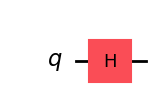

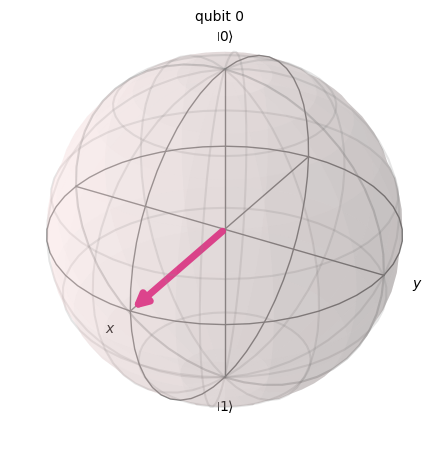

Contagens:
{'1': 519, '0': 505}


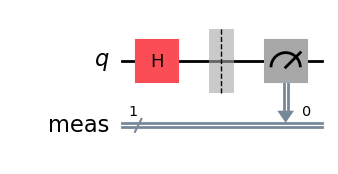

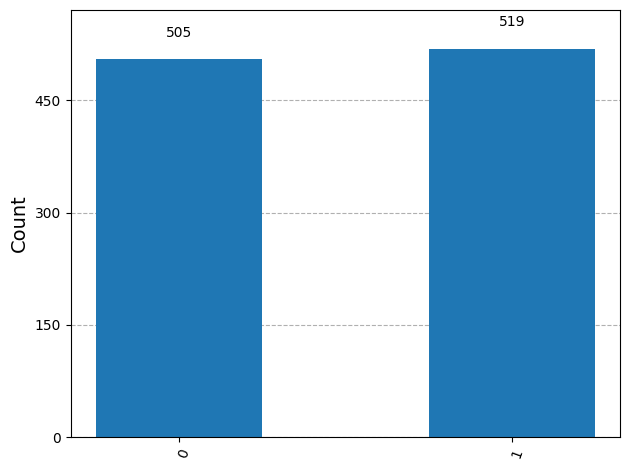

In [ ]:
#LAB4: VISUALIZANDO O ESTADO SUPERPOSIÇÃO E A ESFERA

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import (
    plot_histogram,
    plot_bloch_multivector
)
from IPython.display import display

# -----------------------------------
# 1. Construção do estado quântico
# -----------------------------------

circuito = QuantumCircuit(1)

# Estado inicial: |0>
circuito.h(0)

# -----------------------------------
# 2. Obtenção do vetor de estado
#    ANTES da medição
# -----------------------------------

estado = Statevector.from_instruction(circuito)

print("Vetor de estado:")
print(estado)

# Mostra o circuito
display(circuito.draw(output="mpl"))

# Mostra a esfera de Bloch
display(plot_bloch_multivector(estado))

# -----------------------------------
# 3. Circuito para medição
# -----------------------------------

circuito_medicao = circuito.copy()
circuito_medicao.measure_all()

sampler = StatevectorSampler()

resultado = sampler.run(
    [circuito_medicao],
    shots=1024
).result()

contagens = resultado[0].data.meas.get_counts()

print("Contagens:")
print(contagens)

display(circuito_medicao.draw(output="mpl"))

plot_histogram(contagens)